In [44]:
import pandas as pd
import time
import os
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Setup Data

In [45]:
load_dotenv()
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

file_input = '../Dataset/test_set.csv'
kolom_teks = 'komentar_super_clean'

BATCH_SIZE = 8          
DELAY = 1.5            
CHECKPOINT_FILE = "../Prediction Results/progress_checkpoint.csv"

df = pd.read_csv(file_input)

In [46]:
df_sample = df.copy()

# Checkpoint

In [47]:
if os.path.exists(CHECKPOINT_FILE):
    print("Melanjutkan dari checkpoint...")
    df_sample = pd.read_csv(CHECKPOINT_FILE)
else:
    df_sample['Prediksi_ZeroShot'] = None
    df_sample['Prediksi_FewShot'] = None

# Evaluasi Metriks

In [48]:
def hitung_metrik(y_true, y_pred, nama):
    print(f"\n--- {nama} ---")
    print(f"Akurasi  : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"Recall   : {recall_score(y_true, y_pred)*100:.2f}%")
    print(f"F1 Score : {f1_score(y_true, y_pred)*100:.2f}%")

# GPT

In [49]:
def call_gpt(system_prompt, user_prompt):
    for attempt in range(5):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                temperature=0.0,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ]
            )
            return response.choices[0].message.content

        except Exception as e:
            print(f"Error: {e}")

            if "rate_limit" in str(e):
                print("Rate limit kena, tunggu 15 detik")
                time.sleep(15)
            else:
                time.sleep(3)

    return None

# Prompt untuk GPT

In [50]:
def build_prompt(batch_texts):
    teks_list = ""
    for i, teks in enumerate(batch_texts, 1):
        teks_list += f"{i}. {teks}\n"

    return f"""
Klasifikasikan komentar berikut:

{teks_list}

Jawab STRICT dengan format:
1. PREDIKSI: YA atau TIDAK
2. PREDIKSI: YA atau TIDAK
dst.
"""

# PARSER

In [51]:
def parse_output(output, batch_size):
    hasil = []

    if output is None:
        return [None]*batch_size

    lines = output.upper().split("\n")

    for line in lines:
        if "PREDIKSI" in line:
            if "YA" in line:
                hasil.append(1)
            elif "TIDAK" in line:
                hasil.append(0)

    while len(hasil) < batch_size:
        hasil.append(None)

    return hasil[:batch_size]

# PROMPT ZERO SHOT & FEW SHOT

In [52]:
system_zero = "Kamu adalah sistem deteksi judi online. Jawab hanya dengan 'PREDIKSI: YA' atau 'PREDIKSI: TIDAK'."

system_few = """Kamu adalah pakar pendeteksi spam promosi judi online di Indonesia. Kamu sangat memahami bahasa gaul (slang) akar rumput, istilah gaming, serta taktik penyamaran teks (obfuscation) seperti substitusi angka dan simbol.

Berikut adalah 10 contoh pedoman klasifikasimu:

Contoh 1:
Komentar: "🔥SITUS RESMI🔥 ░S░G░I░8░8░ depo 10k wd 100k 🚀"
Prediksi: YA

Contoh 2:
Komentar: "paling suka model h2, semoga lekas recover mobilnya mas dipo"
Prediksi: TIDAK

Contoh 3:
Komentar: "modal receh main di manut88 pasti banjir scatter tiap hari"
Prediksi: YA

Contoh 4:
Komentar: "bang coba build item mm marksman paling sakit di meta sekarang"
Prediksi: TIDAK

Contoh 5:
Komentar: "malam ini m4nd4l1k477 dan 🅿🆄🅻🅰🆄🆆🅸🅽 lagi bagi bagi freebet merapat bosku"
Prediksi: YA

Contoh 6:
Komentar: "suara burung murai batunya gacor banget om mantap"
Prediksi: TIDAK

Contoh 7:
Komentar: "coba cek link di bio bang, garansi WD tanpa ribet dan rungkad"
Prediksi: YA

Contoh 8:
Komentar: "Yapping mulu anjir kagak ada jawaban sistematis dari tadi"
Prediksi: TIDAK

Contoh 9:
Komentar: "inpo rtp slot yg lagi wangi min, rungkad mulu dari maren"
Prediksi: YA

Contoh 10:
Komentar: "wah gila sih ini editing dan gameplay nya, mekaniknya dapet banget"
Prediksi: TIDAK

Tugasmu: Evaluasi komentar baru berdasarkan pola di atas. Jawab HANYA dengan format 'PREDIKSI: YA' atau 'PREDIKSI: TIDAK' tanpa tambahan penjelasan apapun."""

In [53]:
def run_experiment(system_prompt, kolom_prediksi):
    for i in range(0, len(df_sample), BATCH_SIZE):

        # skip kalau sudah ada hasil
        if pd.notnull(df_sample.loc[i, kolom_prediksi]):
            continue

        batch = df_sample.iloc[i:i+BATCH_SIZE]
        texts = [str(x)[:512] for x in batch[kolom_teks]]

        prompt = build_prompt(texts)
        output = call_gpt(system_prompt, prompt)

        parsed = parse_output(output, len(texts))

        df_sample.loc[i:i+len(parsed)-1, kolom_prediksi] = parsed

        print(f"Batch {i//BATCH_SIZE + 1} selesai")

        # checkpoint setiap batch
        df_sample.to_csv(CHECKPOINT_FILE, index=False)

        time.sleep(DELAY)

# RUN MODEL

In [54]:
print("RUN ZERO-SHOT")
run_experiment(system_zero, 'Prediksi_ZeroShot')

print("RUN FEW-SHOT")
run_experiment(system_few, 'Prediksi_FewShot')

RUN ZERO-SHOT
Batch 1 selesai
Batch 2 selesai
Batch 3 selesai
Batch 4 selesai
Batch 5 selesai
Batch 6 selesai
Batch 7 selesai
Batch 8 selesai
Batch 9 selesai
Batch 10 selesai
Batch 11 selesai
Batch 12 selesai
Batch 13 selesai
Batch 14 selesai
Batch 15 selesai
Batch 16 selesai
Batch 17 selesai
Batch 18 selesai
Batch 19 selesai
Batch 20 selesai
Batch 21 selesai
Batch 22 selesai
Batch 23 selesai
Batch 24 selesai
Batch 25 selesai
Batch 26 selesai
Batch 27 selesai
Batch 28 selesai
Batch 29 selesai
Batch 30 selesai
Batch 31 selesai
Batch 32 selesai
Batch 33 selesai
Batch 34 selesai
Batch 35 selesai
Batch 36 selesai
Batch 37 selesai
Batch 38 selesai
Batch 39 selesai
Batch 40 selesai
Batch 41 selesai
Batch 42 selesai
Batch 43 selesai
Batch 44 selesai
Batch 45 selesai
Batch 46 selesai
Batch 47 selesai
Batch 48 selesai
Batch 49 selesai
Batch 50 selesai
Batch 51 selesai
Batch 52 selesai
Batch 53 selesai
Batch 54 selesai
Batch 55 selesai
Batch 56 selesai
Batch 57 selesai
Batch 58 selesai
Batch 59 

# EVALUASI

In [55]:
df_sample['Prediksi_ZeroShot'] = df_sample['Prediksi_ZeroShot'].astype('Int64')
df_sample['Prediksi_FewShot'] = df_sample['Prediksi_FewShot'].astype('Int64')

mask_zero = df_sample['Prediksi_ZeroShot'].notnull()
mask_few = df_sample['Prediksi_FewShot'].notnull()

hitung_metrik(df_sample.loc[mask_zero, 'label'], df_sample.loc[mask_zero, 'Prediksi_ZeroShot'], "ZERO-SHOT")

hitung_metrik(df_sample.loc[mask_few, 'label'], df_sample.loc[mask_few, 'Prediksi_FewShot'], "FEW-SHOT")


--- ZERO-SHOT ---
Akurasi  : 86.71%
Precision: 94.53%
Recall   : 71.85%
F1 Score : 81.65%

--- FEW-SHOT ---
Akurasi  : 90.57%
Precision: 94.88%
Recall   : 81.47%
F1 Score : 87.67%


In [56]:
df_final = df_sample[[kolom_teks, 'label', 'Prediksi_ZeroShot', 'Prediksi_FewShot']].copy()
df_final.columns = ['Komentar', 'Label', 'ZeroShot', 'FewShot']

df_final.to_csv("../Prediction Results/hasil_gpt_zero_few_final.csv", index=False)

print("\nSELESAI")


SELESAI


# Confusion Matrix

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

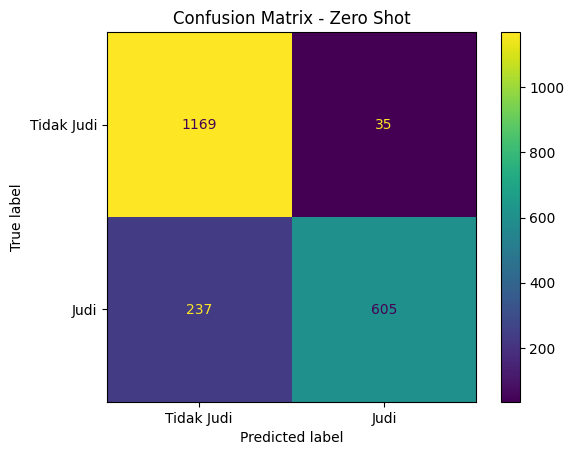

In [58]:
cm_zero = confusion_matrix(
    df_sample.loc[mask_zero, 'label'],
    df_sample.loc[mask_zero, 'Prediksi_ZeroShot']
)

disp_zero = ConfusionMatrixDisplay(confusion_matrix=cm_zero, display_labels=["Tidak Judi", "Judi"])

disp_zero.plot()
plt.title("Confusion Matrix - Zero Shot")
plt.show()


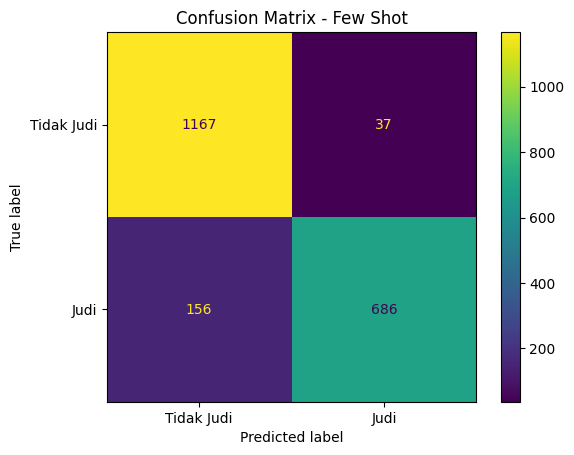

In [59]:
cm_few = confusion_matrix(
    df_sample.loc[mask_few, 'label'],
    df_sample.loc[mask_few, 'Prediksi_FewShot']
)

disp_few = ConfusionMatrixDisplay(confusion_matrix=cm_few, display_labels=["Tidak Judi", "Judi"])

disp_few.plot()
plt.title("Confusion Matrix - Few Shot")
plt.show()